# 10. Метод переноса обучения (Transfer Learning)

**Перенос обучения** - это техника машинного обучения, при которой модель, предварительно обученная на большой dataset (например, ImageNet), используется в качестве отправной точки для решения новой, но схожей задачи.

Основная идея:

- Использовать знания, полученные на большой dataset
- Адаптировать модель для новой задачи с меньшим объемом данных
- Сократить время обучения и улучшить качество


Преимущества переноса обучения:

1.  Экономия времени
2.  Требуется меньше данных - особенно важно для медицинских изображений и т.д.
3.  Лучшая производительность - предобученные модели уже научились полезным признакам
4.  Упрощение процесса - не нужно проектировать архитектуру с нуля


Типы переноса обучения в PyTorch
1. Feature Extraction (Извлечение признаков):

   ### Заморозка всех слоев кроме последнего

```
   for param in model.parameters():
       param.requires_grad = False
   Замена классификатора
   model.fc = nn.Linear(model.fc.in_features, num_classes)
```


2. Fine-Tuning (Тонкая настройка):
   ### Разморозка последних слоев
```
   for param in model.parameters():
       param.requires_grad = False
```
   ### Разморозка последних N слоев
```
   for param in model.layer4.parameters():
       param.requires_grad = True
```
## Порядок работы:

## Шаг 1: Выбор предобученной модели:



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
from typing import Tuple, Dict, List
import pandas as pd

In [2]:
import torchvision.models as models

#Доступные модели (https://docs.pytorch.org/vision/main/models.html#classification)

resnet18 = models.resnet18(pretrained=True)
resnet34 = models.resnet34(pretrained=True)
resnet50 = models.resnet50(pretrained=True)
alexnet = models.alexnet(pretrained=True)


D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the mo

1. Нормализация данных
2. Размер изображений
3. Выбор слоя для замены

## Шаг 2: Адаптация модели под задачу
   

In [32]:
class TransferLearningModel(nn.Module):
    def __init__(self, base_model='resnet18', num_classes=10, freeze_backbone=True):
        super().__init__()

        # Загрузка предобученной модели
        if base_model == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
        elif base_model == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)

        # Заморозка весов
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Замена последнего слоя
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


## Шаг 3: Подготовка данных

In [4]:
def get_data_transforms():
    # Для тренировочных данных - аугментация
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Для тестовых данных - только нормализация
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    return train_transform, test_transform


## Стратегии обучения

## Стратегия 1: Только классификатор


In [5]:
def train_only_classifier(model, train_loader, epochs=10):
    # Заморозка backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Обучение только последнего слоя
    optimizer = optim.Adam(model.backbone.fc.parameters(), lr=0.001)

    for epoch in range(epochs):
      skip
# Процесс обучения...


## Стратегия 2: Поэтапная разморозка


In [6]:
def progressive_unfreezing(model, train_loader, epochs=20):
    # Фаза 1: Только классификатор (эпохи 1-5)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.fc.parameters():
        param.requires_grad = True

    # Фаза 2: Последние слои (эпохи 6-15)
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

    # Фаза 3: Все слои (эпохи 16-20)
    for param in model.parameters():
        param.requires_grad = True

## Стратегия 3: Разные learning rates

In [7]:
def differential_learning_rates(model):
    # Группировка параметров с разными LR
    optimizer = optim.SGD([
        {'params': model.backbone.conv1.parameters(), 'lr': 0.0001},
        {'params': model.backbone.layer1.parameters(), 'lr': 0.001},
        {'params': model.backbone.layer2.parameters(), 'lr': 0.01},
        {'params': model.backbone.fc.parameters(), 'lr': 0.1}
    ], momentum=0.9)


## Перенос обучения:
Хорошо работает когда:
- Мало тренировочных данных (< 10K примеров)
- Новая задача похожа на исходную
- Вычислительные ресурсы ограничены

Менее эффективно когда:
- Новые данные сильно отличаются от исходных
- Очень много данных для новой задачи
- Требуется специализированная архитектура

In [8]:
# !pip install --upgrade torch torchvision torchaudio

In [46]:
backbone = resnet18
# Определение модели с переносом обучения
class TransferLearningModel(nn.Module):
    def __init__(self, base_model = backbone, num_classes: int = 10, freeze_backbone: bool = True):
        """
        Инициализация модели для переноса обучения

        Args:
            base_model: базовая модель ('resnet18', 'resnet34', 'resnet50')
            num_classes: количество классов для классификации
            freeze_backbone: заморозить ли веса базовой модели
        """
        super(TransferLearningModel, self).__init__()

        # Загрузка предобученной модели
        self.backbone = base_model

        # Заморозка весов базовой модели (опционально)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Замена последнего слоя для нашего количества классов
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [10]:
# Функции для работы с данными
def get_data_loaders(batch_size: int = 128) -> Tuple[DataLoader, DataLoader]:
    """
    Создание DataLoader для тренировочных и тестовых данных

    Args:
        batch_size: размер батча

    Returns:
        Кортеж (train_loader, test_loader)
    """
    # Аугментации для тренировочных данных
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Трансформации для тестовых данных
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Загрузка datasets
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    # Создание DataLoader
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [65]:
# Функции для обучения
def train_epoch(model: nn.Module,
                train_loader: DataLoader,
                criterion: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device) -> float:
    """
    Обучение модели на одной эпохе

    Args:
        model: модель для обучения
        train_loader: DataLoader тренировочных данных
        criterion: функция потерь
        optimizer: оптимизатор
        device: устройство (CPU/GPU)

    Returns:
        Среднее значение потерь за эпоху
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    print(f'Train Loss: {avg_loss:.4f} | Train Acc: {accuracy:.2f}%')
    return avg_loss

def evaluate(model: nn.Module,
             test_loader: DataLoader,
             criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    """
    Оценка модели на тестовых данных

    Args:
        model: модель для оценки
        test_loader: DataLoader тестовых данных
        criterion: функция потерь
        device: устройство (CPU/GPU)

    Returns:
        Кортеж (потери, точность)
    """
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = test_loss / len(test_loader)

    print(f'Test Loss: {avg_loss:.4f} | Test Acc: {accuracy:.2f}%')
    return avg_loss, accuracy

def train_model(model: nn.Module,
                train_loader: DataLoader,
                test_loader: DataLoader,
                epochs: int = 10,
                learning_rate: float = 0.001) -> Dict:
    """
    Полный цикл обучения модели

    Args:
        model: модель для обучения
        train_loader: DataLoader тренировочных данных
        test_loader: DataLoader тестовых данных
        epochs: количество эпох
        learning_rate: скорость обучения

    Returns:
        Словарь с историей обучения
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {
        'train_loss': [],
        'test_loss': [],
        'test_accuracy': [],
        'training_time': 0
    }

    start_time = time.time()

    for epoch in range(epochs):
        print(f'\nEpoch: {epoch + 1}/{epochs}')
        print('-' * 50)

        # Обучение
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Оценка
        test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

        # Обновление scheduler
        scheduler.step()

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_accuracy)

    training_time = time.time() - start_time
    history['training_time'] = training_time
    print(f'\nTraining completed in {training_time:.2f} seconds')

    return history

In [36]:
# Функция для создания и обучения модели
def run_transfer_learning_experiment(base_model: str = 'resnet18',
                                   epochs: int = 15,
                                   batch_size: int = 128,
                                   freeze_backbone: bool = True) -> Dict:
    """
    Запуск эксперимента с переносом обучения

    Args:
        base_model: базовая модель
        epochs: количество эпох
        batch_size: размер батча
        freeze_backbone: заморозить ли backbone

    Returns:
        История обучения
    """
    print(f"Starting transfer learning experiment with {base_model}")
    print(f"Freeze backbone: {freeze_backbone}")

    # Создание модели
    model = TransferLearningModel(
        base_model=base_model,
        num_classes=10,
        freeze_backbone=freeze_backbone
    )

    # Получение данных
    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    # Обучение
    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=0.001
    )

    return history

## Задание 1:

- 1.1. Используйте предобученную ResNet-18 для классификации CIFAR-10
- 1.2. Реализуйте два подхода: feature extraction (замороженный backbone) и fine-tuning
- 1.3. Сравните точность и время обучения обоих подходов
- 1.4. Проанализируйте, какой метод работает лучше и почему

In [67]:
def get_data_loaders(batch_size: int = 128) -> Tuple[DataLoader, DataLoader]:
    """
    Создание DataLoader для тренировочных и тестовых данных

    Args:
        batch_size: размер батча

    Returns:
        Кортеж (train_loader, test_loader)
    """
    # Аугментации для тренировочных данных
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Трансформации для тестовых данных
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Загрузка datasets
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    # Создание DataLoader
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [68]:
def print_trainable_summary(model: nn.Module, title: str = ""):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if title:
        print(title)
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.4f}%)")

    names = [n for n, p in model.named_parameters() if p.requires_grad]
    print("Trainable layers:", names[:20], "..." if len(names) > 20 else "")

In [69]:
def run_feature_extraction_experiment(
    epochs: int = 10,
    batch_size: int = 128,
) -> Dict:
    backbone = models.resnet18(pretrained=True)

    model = TransferLearningModel(
        base_model=backbone,
        num_classes=10,
        freeze_backbone=True
    )

    print_trainable_summary(model)

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)
    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=1e-3,
    )

    history["mode"] = "feature_extraction"
    return history


In [70]:
def run_finetuning1_experiment(
    epochs: int = 10,
    batch_size: int = 128,
) -> Dict:
    backbone = models.resnet18(pretrained=True)

    model = TransferLearningModel(
        base_model=backbone,
        num_classes=10,
        freeze_backbone=False
    )

    print_trainable_summary(model)

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=1e-3,
    )

    history["mode"] = "fine_tuning_all"
    return history

In [71]:
def run_finetuning2_experiment(
    epochs: int = 10,
    batch_size: int = 128,
) -> Dict:
    backbone = models.resnet18(pretrained=True)
    model = TransferLearningModel(
        base_model=backbone,
        num_classes=10,
        freeze_backbone=True
    )

    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

    print_trainable_summary(model)

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=1e-3,
    )

    history["mode"] = "fine_tuning_layer4_fc"
    return history

In [74]:
EPOCHS = 10
BATCH_SIZE = 128

print("=== Feature extraction (frozen backbone) ===")
history_fe = run_feature_extraction_experiment(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

print("\n=== Fine-tuning (train all) ===")
history_ft1 = run_finetuning1_experiment(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

print("\n=== Fine-tuning (layer4_fc) ===")
history_ft2 = run_finetuning2_experiment(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

fe_best_acc = max(history_fe["test_accuracy"])
ft1_best_acc = max(history_ft1["test_accuracy"])
ft2_best_acc = max(history_ft2["test_accuracy"])

print("\n=== Сводка ===")
print(f"Feature extraction:             best acc = {fe_best_acc:.2f}%, time = {history_fe['training_time']:.2f}s")
print(f"Fine-tuning (train all):        best acc = {ft1_best_acc:.2f}%, time = {history_ft1['training_time']:.2f}s")
print(f"Fine-tuning (layer4_fc):        best acc = {ft2_best_acc:.2f}%, time = {history_ft2['training_time']:.2f}s")

=== Feature extraction (frozen backbone) ===
Trainable params: 5,130 / 11,181,642 (0.0459%)
Trainable layers: ['backbone.fc.weight', 'backbone.fc.bias'] 
Files already downloaded and verified
Files already downloaded and verified
Using device: cuda

Epoch: 1/10
--------------------------------------------------
Train Loss: 1.8547 | Train Acc: 34.57%
Test Loss: 1.7527 | Test Acc: 39.24%

Epoch: 2/10
--------------------------------------------------
Train Loss: 1.7180 | Train Acc: 39.69%
Test Loss: 1.7147 | Test Acc: 40.40%

Epoch: 3/10
--------------------------------------------------
Train Loss: 1.6945 | Train Acc: 40.78%
Test Loss: 1.7402 | Test Acc: 40.21%

Epoch: 4/10
--------------------------------------------------
Train Loss: 1.6875 | Train Acc: 40.72%
Test Loss: 1.7205 | Test Acc: 39.97%

Epoch: 5/10
--------------------------------------------------
Train Loss: 1.6828 | Train Acc: 41.13%
Test Loss: 1.7312 | Test Acc: 40.02%

Epoch: 6/10
--------------------------------------

## Задание 2: Сравнение архитектур моделей

- 2.1. Выберите 3 различные архитектуры (например, ResNet, VGG, AlexNet)
- 2.2. Примените перенос обучения на CIFAR-10 для каждой архитектуры
- 2.3. Сравните производительность, количество параметров и время сходимости (Таблица сравнения метрик)
- 2.4. Определите наиболее эффективную архитектуру для данной задачи

In [89]:
def get_data_loaders(batch_size: int = 128, img_size: int = 64, num_workers: int = 2):
    train_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(img_size, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])

    test_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])

    train_dataset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=test_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

In [93]:
# У alexnet и vgg16 последний слой - MaxPool2d (или ReLU)
def unfreeze_last_n_convs(features: nn.Module, n: int):
    convs_unfrozen = 0
    for m in reversed(list(features.children())):
        if isinstance(m, nn.Conv2d):
            for p in m.parameters():
                p.requires_grad = True
            convs_unfrozen += 1
            if convs_unfrozen >= n:
                break
    return convs_unfrozen

def create_model_for_architecture(
    arch_name: str,
    num_classes: int = 10,
    mode: str = "fe",          # "fe" или "ft_last"
    pretrained: bool = True
) -> nn.Module:
    if arch_name == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        # freeze всё
        for p in model.parameters():
            p.requires_grad = False
        # head trainable
        for p in model.fc.parameters():
            p.requires_grad = True

        # ft_last: layer4 + fc
        if mode == "ft_last":
            for p in model.layer4.parameters():
                p.requires_grad = True

    elif arch_name == "vgg16":
        model = models.vgg16(pretrained=pretrained)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

        # freeze всё
        for p in model.parameters():
            p.requires_grad = False
        # head trainable (только последний Linear)
        for p in model.classifier[-1].parameters():
            p.requires_grad = True

        # ft_last: разморозим последний conv-блок (3 conv слоя)
        if mode == "ft_last":
            unfreeze_last_n_convs(model.features, n=3)

    elif arch_name == "alexnet":
        model = models.alexnet(pretrained=pretrained)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

        # freeze всё
        for p in model.parameters():
            p.requires_grad = False
        # head trainable (только последний Linear)
        for p in model.classifier[-1].parameters():
            p.requires_grad = True

        # ft_last: разморозим последние 2 conv слоя (conv4+conv5)
        if mode == "ft_last":
            unfreeze_last_n_convs(model.features, n=2)

    else:
        raise ValueError(f"Неизвестная архитектура: {arch_name}")

    return model


In [94]:
def run_architecture_experiment(
    arch_name: str,
    epochs: int = 10,
    batch_size: int = 128,
    mode: str = "fe"   # "fe" или "ft_last"
) -> Dict:
    mode = mode.lower()
    title = "feature extraction" if mode == "fe" else "fine-tuning (last block)"

    print(f"\n=== Архитектура: {arch_name}, {title} ===")

    model = create_model_for_architecture(
        arch_name=arch_name,
        num_classes=10,
        mode=mode,
        pretrained=True
    )

    print_trainable_summary(model)
    # из-за Resize растёт точность, а он нужен для alexnet
    train_loader, test_loader = get_data_loaders(batch_size=batch_size, img_size=64)

    lr = 1e-3

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=lr
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    history["arch_name"] = arch_name
    history["mode"] = mode
    history["total_params"] = total_params
    history["trainable_params"] = trainable_params

    return history


In [95]:
EPOCHS = 10
BATCH_SIZE = 128

architectures = ["resnet18", "vgg16", "alexnet"]
modes = ["fe", "ft_last"]

histories = []
results = []

for mode in modes:
    for arch in architectures:
        history = run_architecture_experiment(
            arch_name=arch,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            mode=mode
        )
        histories.append(history)

        best_acc = max(history["test_accuracy"])
        total_params_m = history["total_params"] / 1e6
        trainable_params_m = history["trainable_params"] / 1e6
        training_time = history["training_time"]

        results.append({
            "Architecture": arch,
            "Mode": "Feature extraction" if mode == "fe" else "Fine-tuning (last block)",
            "Best accuracy (%)": best_acc,
            "Training time (s)": training_time,
            "Total params (M)": total_params_m,
            "Trainable params (M)": trainable_params_m
        })


=== Архитектура: resnet18, feature extraction ===
Trainable params: 5,130 / 11,181,642 (0.0459%)
Trainable layers: ['fc.weight', 'fc.bias'] 
Files already downloaded and verified
Files already downloaded and verified
Using device: cuda

Epoch: 1/10
--------------------------------------------------
Train Loss: 1.4791 | Train Acc: 49.38%
Test Loss: 1.3603 | Test Acc: 54.06%

Epoch: 2/10
--------------------------------------------------
Train Loss: 1.2900 | Train Acc: 55.57%
Test Loss: 1.2774 | Test Acc: 56.94%

Epoch: 3/10
--------------------------------------------------
Train Loss: 1.2566 | Train Acc: 56.83%
Test Loss: 1.2698 | Test Acc: 57.47%

Epoch: 4/10
--------------------------------------------------
Train Loss: 1.2556 | Train Acc: 57.08%
Test Loss: 1.3044 | Test Acc: 55.86%

Epoch: 5/10
--------------------------------------------------
Train Loss: 1.2389 | Train Acc: 57.66%
Test Loss: 1.2591 | Test Acc: 57.75%

Epoch: 6/10
--------------------------------------------------

In [96]:
df_results = pd.DataFrame(results)
print("\n=== Таблица сравнения моделей (FE vs FT_last) ===")
print(df_results)


=== Таблица сравнения моделей (FE vs FT_last) ===
  Architecture                      Mode  Best accuracy (%)  \
0     resnet18        Feature extraction              57.86   
1        vgg16        Feature extraction              71.44   
2      alexnet        Feature extraction              59.01   
3     resnet18  Fine-tuning (last block)              85.80   
4        vgg16  Fine-tuning (last block)              88.90   
5      alexnet  Fine-tuning (last block)              78.26   

   Training time (s)  Total params (M)  Trainable params (M)  
0         220.220160         11.181642              0.005130  
1         528.419908        134.301514              0.040970  
2         220.627238         57.044810              0.040970  
3         240.728053         11.181642              8.398858  
4         612.024970        134.301514              7.120394  
5         228.676452         57.044810              1.516042  


## Задание 3: Влияние размера обучающей выборки
- 3.1. dataset CIFAR-10
- 3.2. Создайте подвыборки разного размера (1%, 5%, 10%, 25%, 50%, 100% данных)
- 3.3. Для каждого размера обучите модель с переносом обучения (Таблица сравнения метрик)
- 3.4. Постройте график зависимости точности от размера выборки
- 3.5. Проанализируйте кривую обучения

In [97]:
from torch.utils.data import Subset

def get_subset_loaders(
    train_fraction: float,
    batch_size: int = 128,
    seed: int = 2
) -> Tuple[DataLoader, DataLoader]:

    train_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(64, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    test_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    full_train_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=train_transform,
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=test_transform,
    )

    num_train = len(full_train_dataset)
    subset_size = max(1, int(num_train * train_fraction))

    g = torch.Generator().manual_seed(seed)
    indices = torch.randperm(num_train, generator=g)[:subset_size]
    subset_train_dataset = Subset(full_train_dataset, indices)

    train_loader = DataLoader(subset_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader


In [98]:
def create_resnet18_for_mode(num_classes: int = 10, mode: str = "fe", pretrained: bool = True) -> nn.Module:
    mode = mode.lower()

    model = models.resnet18(pretrained=pretrained)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # Заморозить всё
    for p in model.parameters():
        p.requires_grad = False

    # Голова всегда обучаемая
    for p in model.fc.parameters():
        p.requires_grad = True

    # Fine-tuning последних слоёв: layer4 + fc
    if mode == "ft_last":
        for p in model.layer4.parameters():
            p.requires_grad = True

    return model

In [99]:
def run_data_size_experiment(
    train_fraction: float,
    epochs: int = 10,
    batch_size: int = 128,
    mode: str = "fe"    # "fe" или "ft_last"
) -> Dict:
    title = "feature extraction" if mode == "fe" else "fine-tuning (layer4 + fc)"
    print(f"\n=== Доля обучающей выборки: {train_fraction*100:.1f}% | mode: {title} ===")

    model = create_resnet18_for_mode(num_classes=10, mode=mode, pretrained=True)

    # Для защиты: показать, что реально обучается
    print_trainable_summary(model)

    train_loader, test_loader = get_subset_loaders(
        train_fraction=train_fraction,
        batch_size=batch_size
    )

    lr = 1e-3

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=lr
    )

    history["train_fraction"] = train_fraction
    history["subset_size"] = len(train_loader.dataset)
    history["mode"] = mode
    return history

In [101]:
EPOCHS = 10
BATCH_SIZE = 128

fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
modes = ["fe", "ft_last"]

histories_sizes = []
rows = []

for mode in modes:
    for frac in fractions:
        history = run_data_size_experiment(
            train_fraction=frac,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            mode=mode
        )
        histories_sizes.append(history)

        best_acc = max(history["test_accuracy"])
        training_time = history["training_time"]
        subset_size = history["subset_size"]

        rows.append({
            "Mode": "Feature extraction" if mode == "fe" else "Fine-tuning (layer4+fc)",
            "Train fraction": frac,
            "Train size": subset_size,
            "Best accuracy (%)": best_acc,
            "Training time (s)": training_time,
        })

df_sizes = pd.DataFrame(rows)
print("\n=== Таблица: CIFAR-10 — влияние размера выборки (FE vs FT_last) ===")
print(df_sizes)



=== Доля обучающей выборки: 1.0% | mode: feature extraction ===


D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trainable params: 5,130 / 11,181,642 (0.0459%)
Trainable layers: ['fc.weight', 'fc.bias'] 
Files already downloaded and verified
Files already downloaded and verified
Using device: cuda

Epoch: 1/10
--------------------------------------------------
Train Loss: 2.4969 | Train Acc: 11.00%
Test Loss: 2.5450 | Test Acc: 13.64%

Epoch: 2/10
--------------------------------------------------
Train Loss: 2.3546 | Train Acc: 17.00%
Test Loss: 2.3371 | Test Acc: 18.87%

Epoch: 3/10
--------------------------------------------------
Train Loss: 2.1106 | Train Acc: 22.80%
Test Loss: 2.1938 | Test Acc: 23.38%

Epoch: 4/10
--------------------------------------------------
Train Loss: 1.9965 | Train Acc: 30.40%
Test Loss: 2.0825 | Test Acc: 26.66%

Epoch: 5/10
--------------------------------------------------
Train Loss: 1.9297 | Train Acc: 30.20%
Test Loss: 2.0264 | Test Acc: 29.01%

Epoch: 6/10
--------------------------------------------------
Train Loss: 1.8039 | Train Acc: 37.20%
Test Loss: 

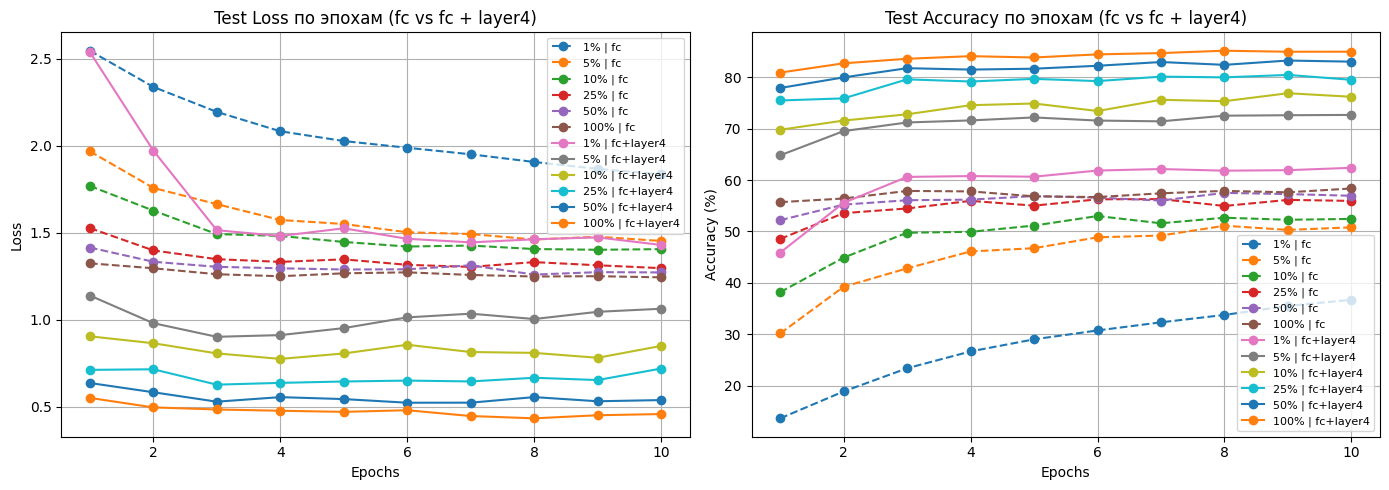

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ---------- 1) TEST LOSS ----------
plt.subplot(1, 2, 1)

for h in histories_sizes:
    frac = int(h["train_fraction"] * 100)
    mode = h["mode"]
    epochs = range(1, len(h["test_loss"]) + 1)

    linestyle = "--" if mode == "fe" else "-"
    label = f"{frac}% | {'fc' if mode == 'fe' else 'fc+layer4'}"

    plt.plot(
        epochs,
        h["test_loss"],
        linestyle=linestyle,
        marker="o",
        label=label
    )

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Test Loss по эпохам (fc vs fc + layer4)")
plt.grid(True)
plt.legend(fontsize=8)

# ---------- 2) TEST ACCURACY ----------
plt.subplot(1, 2, 2)

for h in histories_sizes:
    frac = int(h["train_fraction"] * 100)
    mode = h["mode"]
    epochs = range(1, len(h["test_accuracy"]) + 1)

    acc = [a for a in h["test_accuracy"]]
    linestyle = "--" if mode == "fe" else "-"
    label = f"{frac}% | {'fc' if mode == 'fe' else 'fc+layer4'}"

    plt.plot(
        epochs,
        acc,
        linestyle=linestyle,
        marker="o",
        label=label
    )

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy по эпохам (fc vs fc + layer4)")
plt.grid(True)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Задание 4: Поэтапное размораживание слоев
- 4.1. Реализуйте стратегию постепенного размораживания слоев ResNet-18.
- 4.2. Начните с замороженного backbone, обучайте только классификатор.
- 4.3. Разморозьте и дообучите последний блок слоев.
- 4.4. Наконец, разморозьте всю модель.
- 4.5. Сравните с одноэтапным fine-tuning.

Визуализация процесса обучения для каждого этапа.
Сравнение стабильности обучения и конечной точности.

In [23]:
def set_trainable_resnet18_layers(model: nn.Module, mode: str = "fc_only"):
    mode = mode.lower()

    for param in model.parameters():
        param.requires_grad = False

    if mode == "fc_only":
        for param in model.fc.parameters():
            param.requires_grad = True

    elif mode == "layer4_plus_fc":
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True

    elif mode == "all":
        for param in model.parameters():
            param.requires_grad = True

In [24]:
def train_resnet18_with_progressive_unfreezing(
    epochs_per_stage=(3, 3, 3),
    batch_size: int = 128
) -> Dict[str, list]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    model = models.resnet18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    stages = [
        {"name": "fc_only",         "mode": "fc_only",         "epochs": epochs_per_stage[0], "lr": 1e-3},
        {"name": "layer4_plus_fc",  "mode": "layer4_plus_fc",  "epochs": epochs_per_stage[1], "lr": 1e-4},
        {"name": "full_finetune",   "mode": "all",             "epochs": epochs_per_stage[2], "lr": 1e-5},
    ]

    history = {
        "epoch": [],
        "stage": [],
        "train_loss": [],
        "test_loss": [],
        "test_accuracy": [],
        "training_time": 0.0
    }

    global_epoch = 0
    start_time = time.time()

    for stage in stages:
        print(f"\n=== Stage: {stage['name']} | mode = {stage['mode']} ===")

        set_trainable_resnet18_layers(model, mode=stage["mode"])

        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=stage["lr"])
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(1, stage["epochs"] // 2), gamma=0.1)

        for e in range(stage["epochs"]):
            global_epoch += 1
            print(f"Stage {stage['name']} | Epoch [{e+1}/{stage['epochs']}] (global {global_epoch})")

            train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)
            scheduler.step()

            history["epoch"].append(global_epoch)
            history["stage"].append(stage["name"])
            history["train_loss"].append(train_loss)
            history["test_loss"].append(test_loss)
            history["test_accuracy"].append(test_acc)

            print(
                f"Train loss: {train_loss:.4f} | "
                f"Test loss: {test_loss:.4f} | "
                f"Test accuracy: {test_acc*100:.2f}%"
            )

    total_time = time.time() - start_time
    history["training_time"] = total_time
    print(f"\n[Progressive unfreezing] Training completed in {total_time:.2f} seconds")

    return history

In [25]:
def train_resnet18_oneshot_finetune(
    epochs: int = 9,
    batch_size: int = 128,
    learning_rate: float = 1e-4
) -> Dict[str, list]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    model = models.resnet18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_accuracy": [],
        "training_time": 0.0
    }

    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_acc)

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Test loss: {test_loss:.4f} | "
            f"Test accuracy: {test_acc*100:.2f}%"
        )

    total_time = time.time() - start_time
    history["training_time"] = total_time
    print(f"\n[One-shot fine-tuning] Training completed in {total_time:.2f} seconds")

    return history

In [26]:
EPOCHS_PER_STAGE = (3, 3, 3)
TOTAL_EPOCHS = sum(EPOCHS_PER_STAGE)
BATCH_SIZE = 128

print("=== Progressive unfreezing ===")
history_prog = train_resnet18_with_progressive_unfreezing(
    epochs_per_stage=EPOCHS_PER_STAGE,
    batch_size=BATCH_SIZE
)

print("\n\n=== One-shot fine-tuning ===")
history_ft = train_resnet18_oneshot_finetune(
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=1e-4
)

prog_best_acc = max(history_prog["test_accuracy"])
ft_best_acc = max(history_ft["test_accuracy"])

print("\n=== Итоговое сравнение ===")
print(f"Progressive unfreezing: "
      f"лучшая точность = {prog_best_acc*100:.2f}%, "
      f"время обучения = {history_prog['training_time']:.2f} сек")

print(f"One-shot fine-tuning:   "
      f"лучшая точность = {ft_best_acc*100:.2f}%, "
      f"время обучения = {history_ft['training_time']:.2f} сек")

=== Progressive unfreezing ===
Device: cuda
Files already downloaded and verified
Files already downloaded and verified


D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== Stage: fc_only | mode = fc_only ===
Stage fc_only | Epoch [1/3] (global 1)
Train loss: 0.9982 | Test loss: 0.7027 | Test accuracy: 76.27%
Stage fc_only | Epoch [2/3] (global 2)
Train loss: 0.7184 | Test loss: 0.6805 | Test accuracy: 77.26%
Stage fc_only | Epoch [3/3] (global 3)
Train loss: 0.7109 | Test loss: 0.6759 | Test accuracy: 77.61%

=== Stage: layer4_plus_fc | mode = layer4_plus_fc ===
Stage layer4_plus_fc | Epoch [1/3] (global 4)
Train loss: 0.4049 | Test loss: 0.3127 | Test accuracy: 89.42%
Stage layer4_plus_fc | Epoch [2/3] (global 5)
Train loss: 0.2487 | Test loss: 0.2756 | Test accuracy: 90.52%
Stage layer4_plus_fc | Epoch [3/3] (global 6)
Train loss: 0.2291 | Test loss: 0.2754 | Test accuracy: 90.54%

=== Stage: full_finetune | mode = all ===
Stage full_finetune | Epoch [1/3] (global 7)
Train loss: 0.2021 | Test loss: 0.2230 | Test accuracy: 92.53%
Stage full_finetune | Epoch [2/3] (global 8)
Train loss: 0.1702 | Test loss: 0.2180 | Test accuracy: 92.85%
Stage full_f

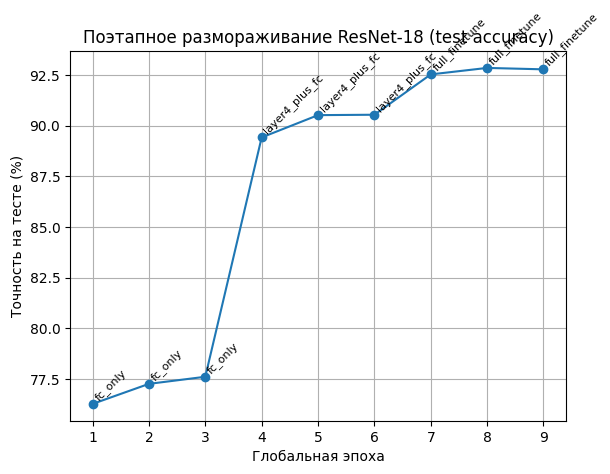

In [27]:
import matplotlib.pyplot as plt

epochs = history_prog["epoch"]
acc_prog = [a * 100 for a in history_prog["test_accuracy"]]
stages = history_prog["stage"]

plt.figure()
plt.plot(epochs, acc_prog, marker="o")
for i, st in enumerate(stages):
    # подпишем точки этапа (опционально)
    plt.text(epochs[i], acc_prog[i] + 0.2, st, fontsize=8, rotation=45)

plt.xlabel("Глобальная эпоха")
plt.ylabel("Точность на тесте (%)")
plt.title("Поэтапное размораживание ResNet-18 (test accuracy)")
plt.grid(True)
plt.show()

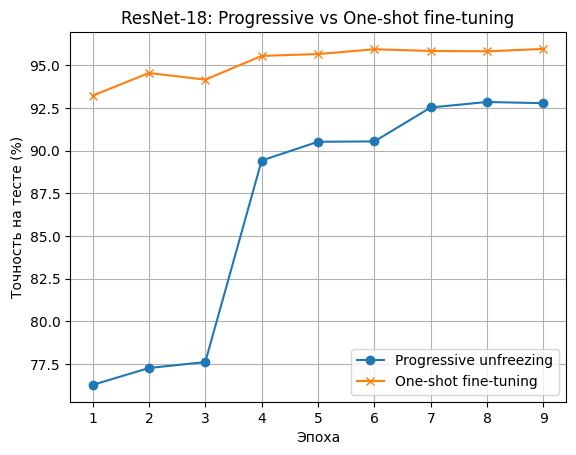

In [30]:
acc_ft = [a * 100 for a in history_ft["test_accuracy"]]
global_epochs = list(range(1, TOTAL_EPOCHS + 1))

plt.figure()
plt.plot(global_epochs, acc_prog, marker="o", label="Progressive unfreezing")
plt.plot(global_epochs, acc_ft, marker="x", label="One-shot fine-tuning")
plt.xlabel("Эпоха")
plt.ylabel("Точность на тесте (%)")
plt.title("ResNet-18: Progressive vs One-shot fine-tuning")
plt.legend()
plt.grid(True)
plt.show()

## Задание 5: Адаптация под другую задачу - бинарная классификация

- 5.1. Используйте Food101 (https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.Food101.html#torchvision.datasets.Food101)
- 5.2. Настройте предобученную модель для классификации Food101
- 5.3. Экспериментируйте с различными функциями активации на выходе
- 5.4. Сравните разные стратегии инициализации последнего слоя

In [32]:
from torchvision.datasets import Food101

def get_food101_loaders(
    batch_size: int = 64
) -> Tuple[DataLoader, DataLoader]:
    imagenet_mean = (0.485, 0.456, 0.406)
    imagenet_std  = (0.229, 0.224, 0.225)

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])

    train_dataset = Food101(
        root="./data",
        split="train",
        download=True,
        transform=train_transform,
        target_transform=None
    )

    test_dataset = Food101(
        root="./data",
        split="test",
        download=True,
        transform=test_transform,
        target_transform=None
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [33]:
class ResNet18BinaryHead(nn.Module):
    def __init__(self,
                 mode: str = "ce",
                 pretrained: bool = True):
        super().__init__()
        assert mode in ["ce", "bce"] # CrossEntropyLoss, BCEWithLogitsLoss
        self.mode = mode

        self.backbone = torchvision.models.resnet18(pretrained=pretrained)
        in_features = self.backbone.fc.in_features

        if mode == "ce":
            self.backbone.fc = nn.Linear(in_features, 2)
        else:
            self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

In [34]:
def init_last_layer(model: ResNet18BinaryHead, init_type: str = "default"):
    init_type = init_type.lower()
    if init_type == "default":
        return

    fc = model.backbone.fc

    if init_type == "xavier":
        nn.init.xavier_uniform_(fc.weight)
        if fc.bias is not None:
            nn.init.zeros_(fc.bias)
    elif init_type == "kaiming":
        nn.init.kaiming_normal_(fc.weight, nonlinearity="relu")
        if fc.bias is not None:
            nn.init.zeros_(fc.bias)
    elif init_type == "zero":
        nn.init.zeros_(fc.weight)
        if fc.bias is not None:
            nn.init.zeros_(fc.bias)

In [35]:
def train_epoch_food101_binary(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    loss_mode: str,
    class_pos: str,
    class_neg: str,
    optimizer: optim.Optimizer
) -> float:
    model.train()
    running_loss = 0.0
    total = 0

    # индексы классов в оригинальном Food101
    class_to_idx = train_loader.dataset.class_to_idx
    idx_pos = class_to_idx[class_pos]
    idx_neg = class_to_idx[class_neg]

    for inputs, targets in train_loader:
        mask = (targets == idx_pos) | (targets == idx_neg)
        if mask.sum().item() == 0:
            continue

        inputs = inputs[mask].to(device)
        targets = targets[mask]

        if loss_mode == "ce":
            targets_bin = (targets == idx_pos).long().to(device)
        else:
            targets_bin = (targets == idx_pos).float().view(-1, 1).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets_bin)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        total += inputs.size(0)

    epoch_loss = running_loss / max(total, 1)
    return epoch_loss


@torch.no_grad()
def evaluate_food101_binary(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    loss_mode: str,
    class_pos: str,
    class_neg: str
) -> Tuple[float, float]:
    
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    class_to_idx = data_loader.dataset.class_to_idx
    idx_pos = class_to_idx[class_pos]
    idx_neg = class_to_idx[class_neg]

    for inputs, targets in data_loader:
        mask = (targets == idx_pos) | (targets == idx_neg)
        if mask.sum().item() == 0:
            continue

        inputs = inputs[mask].to(device)
        targets = targets[mask]

        if loss_mode == "ce":
            targets_bin = (targets == idx_pos).long().to(device)
        else:
            targets_bin = (targets == idx_pos).float().view(-1, 1).to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets_bin)
        running_loss += loss.item() * inputs.size(0)

        if loss_mode == "ce":
            _, predicted = outputs.max(1)
            correct += (predicted == targets_bin).sum().item()
        else:
            probs = torch.sigmoid(outputs)
            predicted = (probs >= 0.5).long()
            correct += (predicted.view(-1) == targets_bin.view(-1).long()).sum().item()

        total += inputs.size(0)

    epoch_loss = running_loss / max(total, 1)
    accuracy = correct / max(total, 1)
    return epoch_loss, accuracy

In [36]:
def train_food101_binary_model(
    loss_mode: str = "ce",          # "ce" или "bce"
    init_type: str = "default",     # "default", "xavier", "kaiming", "zero"
    class_pos: str = "pizza",
    class_neg: str = "apple_pie",
    batch_size: int = 64,
    epochs: int = 3,
    learning_rate: float = 1e-4
) -> Dict[str, List[float]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_loader, test_loader = get_food101_loaders(batch_size=batch_size)

    model = ResNet18BinaryHead(mode=loss_mode, pretrained=True)
    init_last_layer(model, init_type=init_type)
    model.to(device)

    if loss_mode == "ce":
        criterion = nn.CrossEntropyLoss()
    elif loss_mode == "bce":
        criterion = nn.BCEWithLogitsLoss()
        
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 2), gamma=0.1)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_accuracy": [],
        "training_time": 0.0
    }

    start_time = time.time()

    for epoch in range(epochs):
        print(f"\nEpoch [{epoch+1}/{epochs}] | "
              f"loss_mode={loss_mode}, init={init_type}")
        train_loss = train_epoch_food101_binary(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            device=device,
            loss_mode=loss_mode,
            class_pos=class_pos,
            class_neg=class_neg,
            optimizer=optimizer
        )
        test_loss, test_acc = evaluate_food101_binary(
            model=model,
            data_loader=test_loader,
            criterion=criterion,
            device=device,
            loss_mode=loss_mode,
            class_pos=class_pos,
            class_neg=class_neg
        )
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_acc)

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Test loss: {test_loss:.4f} | "
            f"Test accuracy: {test_acc*100:.2f}%"
        )

    total_time = time.time() - start_time
    history["training_time"] = total_time
    print(f"\n[Food101 binary] Training completed in {total_time:.2f} seconds")

    return history

In [44]:
configs = [
    {"name": "CE_default", "loss_mode": "ce",  "init_type": "default"},
    {"name": "CE_xavier",  "loss_mode": "ce",  "init_type": "xavier"},
    {"name": "BCE_default","loss_mode": "bce", "init_type": "default"},
    {"name": "BCE_kaiming","loss_mode": "bce", "init_type": "kaiming"},
]

all_histories = {}
rows = []

for cfg in configs:
    print("\n==============================")
    print(f"Config: {cfg['name']}")
    print("==============================")

    hist = train_food101_binary_model(
        loss_mode=cfg["loss_mode"],
        init_type=cfg["init_type"],
        class_pos="pizza",
        class_neg="apple_pie",
        batch_size=64,
        epochs=3,
        learning_rate=1e-4
    )

    all_histories[cfg["name"]] = hist
    best_acc = max(hist["test_accuracy"])

    rows.append({
        "Config": cfg["name"],
        "Loss mode": cfg["loss_mode"],
        "Init": cfg["init_type"],
        "Best accuracy (%)": best_acc * 100,
        "Training time (s)": hist["training_time"],
    })

df_food = pd.DataFrame(rows)
print("\n=== Результаты экспериментов Food101 (бинарная классификация) ===")
print(df_food)


Config: CE_default
Device: cuda
Using downloaded and verified file: ./data\food-101.tar.gz
Extracting ./data\food-101.tar.gz to ./data


D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch [1/3] | loss_mode=ce, init=default
Train loss: 0.5819 | Test loss: 0.3390 | Test accuracy: 84.40%

Epoch [2/3] | loss_mode=ce, init=default
Train loss: 0.4851 | Test loss: 0.2514 | Test accuracy: 88.00%

Epoch [3/3] | loss_mode=ce, init=default
Train loss: 0.4405 | Test loss: 0.2147 | Test accuracy: 91.00%

[Food101 binary] Training completed in 673.43 seconds

Config: CE_xavier
Device: cuda

Epoch [1/3] | loss_mode=ce, init=xavier
Train loss: 0.6483 | Test loss: 0.6407 | Test accuracy: 72.20%

Epoch [2/3] | loss_mode=ce, init=xavier
Train loss: 0.5348 | Test loss: 0.1987 | Test accuracy: 92.80%

Epoch [3/3] | loss_mode=ce, init=xavier
Train loss: 0.5036 | Test loss: 0.1882 | Test accuracy: 93.60%

[Food101 binary] Training completed in 652.06 seconds

Config: BCE_default
Device: cuda

Epoch [1/3] | loss_mode=bce, init=default
Train loss: 0.5657 | Test loss: 0.2691 | Test accuracy: 89.40%

Epoch [2/3] | loss_mode=bce, init=default
Train loss: 0.5158 | Test loss: 0.1637 | Test ac

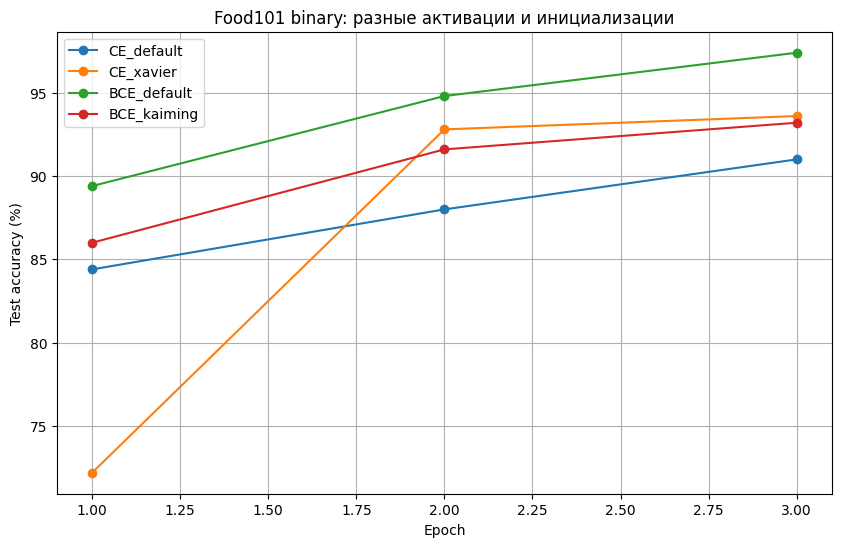

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, hist in all_histories.items():
    acc = [a * 100 for a in hist["test_accuracy"]]
    plt.plot(range(1, len(acc) + 1), acc, marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Food101 binary: разные активации и инициализации")
plt.grid(True)
plt.legend()
plt.show()
